In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df_bureau= pd.read_csv('dataset/bureau_data.csv')
df_customers= pd.read_csv('dataset/customers.csv')
df_loans= pd.read_csv('dataset/loans.csv')

df_bureau.shape, df_customers.shape, df_loans.shape

((50000, 8), (50000, 12), (50000, 15))

In [3]:
df_bureau.head(3)

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58


In [4]:
df_loans.head(3)

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,24-07-2019,10-08-2019,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,24-07-2019,15-08-2019,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,24-07-2019,21-08-2019,False


In [5]:
df_customers.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001


In [6]:
df= pd.merge(df_customers, df_loans, on='cust_id')
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.0,444060,1973600,33,1630408,873386,24-07-2019,10-08-2019,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.0,698940,3106400,30,709309,464100,24-07-2019,15-08-2019,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.0,390600,1736000,21,1562399,1476042,24-07-2019,21-08-2019,False


In [7]:
df= pd.merge(df, df_bureau, on='cust_id')
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,24-07-2019,10-08-2019,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,24-07-2019,15-08-2019,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,24-07-2019,21-08-2019,False,2,1,82,24,147,6,58


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  str    
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  str    
 3   marital_status               50000 non-null  str    
 4   employment_status            50000 non-null  str    
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  str    
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  str    
 10  state                        50000 non-null  str    
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  str    
 13  loan_purpose               

In [9]:
df['default']= df['default'].astype(int)  #here in the target variable(default), it has data imbalance, we'll address it later
df['default'].value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

In [10]:
# here we doing data split before EDA, because we don't want our test data influence our feature engineering, & decision making

X= df.drop('default', axis=1)
y= df['default']

X_train, X_test, y_train, y_test= train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

df_train= pd.concat([X_train, y_train], axis=1)
df_test= pd.concat([X_test, y_test], axis=1)

df_train.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,31-10-2020,11-11-2020,4,2,152,20,118,4,36,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,22-10-2022,27-10-2022,3,1,160,10,62,5,5,0
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,...,04-12-2023,29-12-2023,1,1,54,12,67,4,0,0


In [11]:
# data cleaning

# handling missing values

df_train.shape

(37500, 33)

In [12]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [13]:
df.residence_type.unique()

<ArrowStringArray>
['Owned', 'Mortgage', 'Rented', nan]
Length: 4, dtype: str

In [14]:
mode_residence= df_train.residence_type.mode()[0]
mode_residence

'Owned'

In [15]:
# mode value of residence type is 'owned'. so replacing the NaN values with mode to both train & test data

df_train['residence_type']= df_train.residence_type.fillna(mode_residence)
df_test['residence_type']= df_test.residence_type.fillna(mode_residence)

df_train['residence_type'].isna().sum()

np.int64(0)

In [16]:
df_test['residence_type'].unique()

<ArrowStringArray>
['Owned', 'Mortgage', 'Rented']
Length: 3, dtype: str

In [17]:
df_train.duplicated().sum()

np.int64(0)

In [18]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='str')

In [19]:
columns_continuous = ['age', 'income', 'number_of_dependants', 'years_at_current_address', 
                      'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement', 
                      'loan_tenure_months','principal_outstanding', 'bank_balance_at_application',
                      'number_of_open_accounts','number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
                       'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

columns_categorical = ['gender', 'marital_status', 'employment_status', 'residence_type', 'city', 
                       'state', 'zipcode', 'loan_purpose', 'loan_type', 'default']

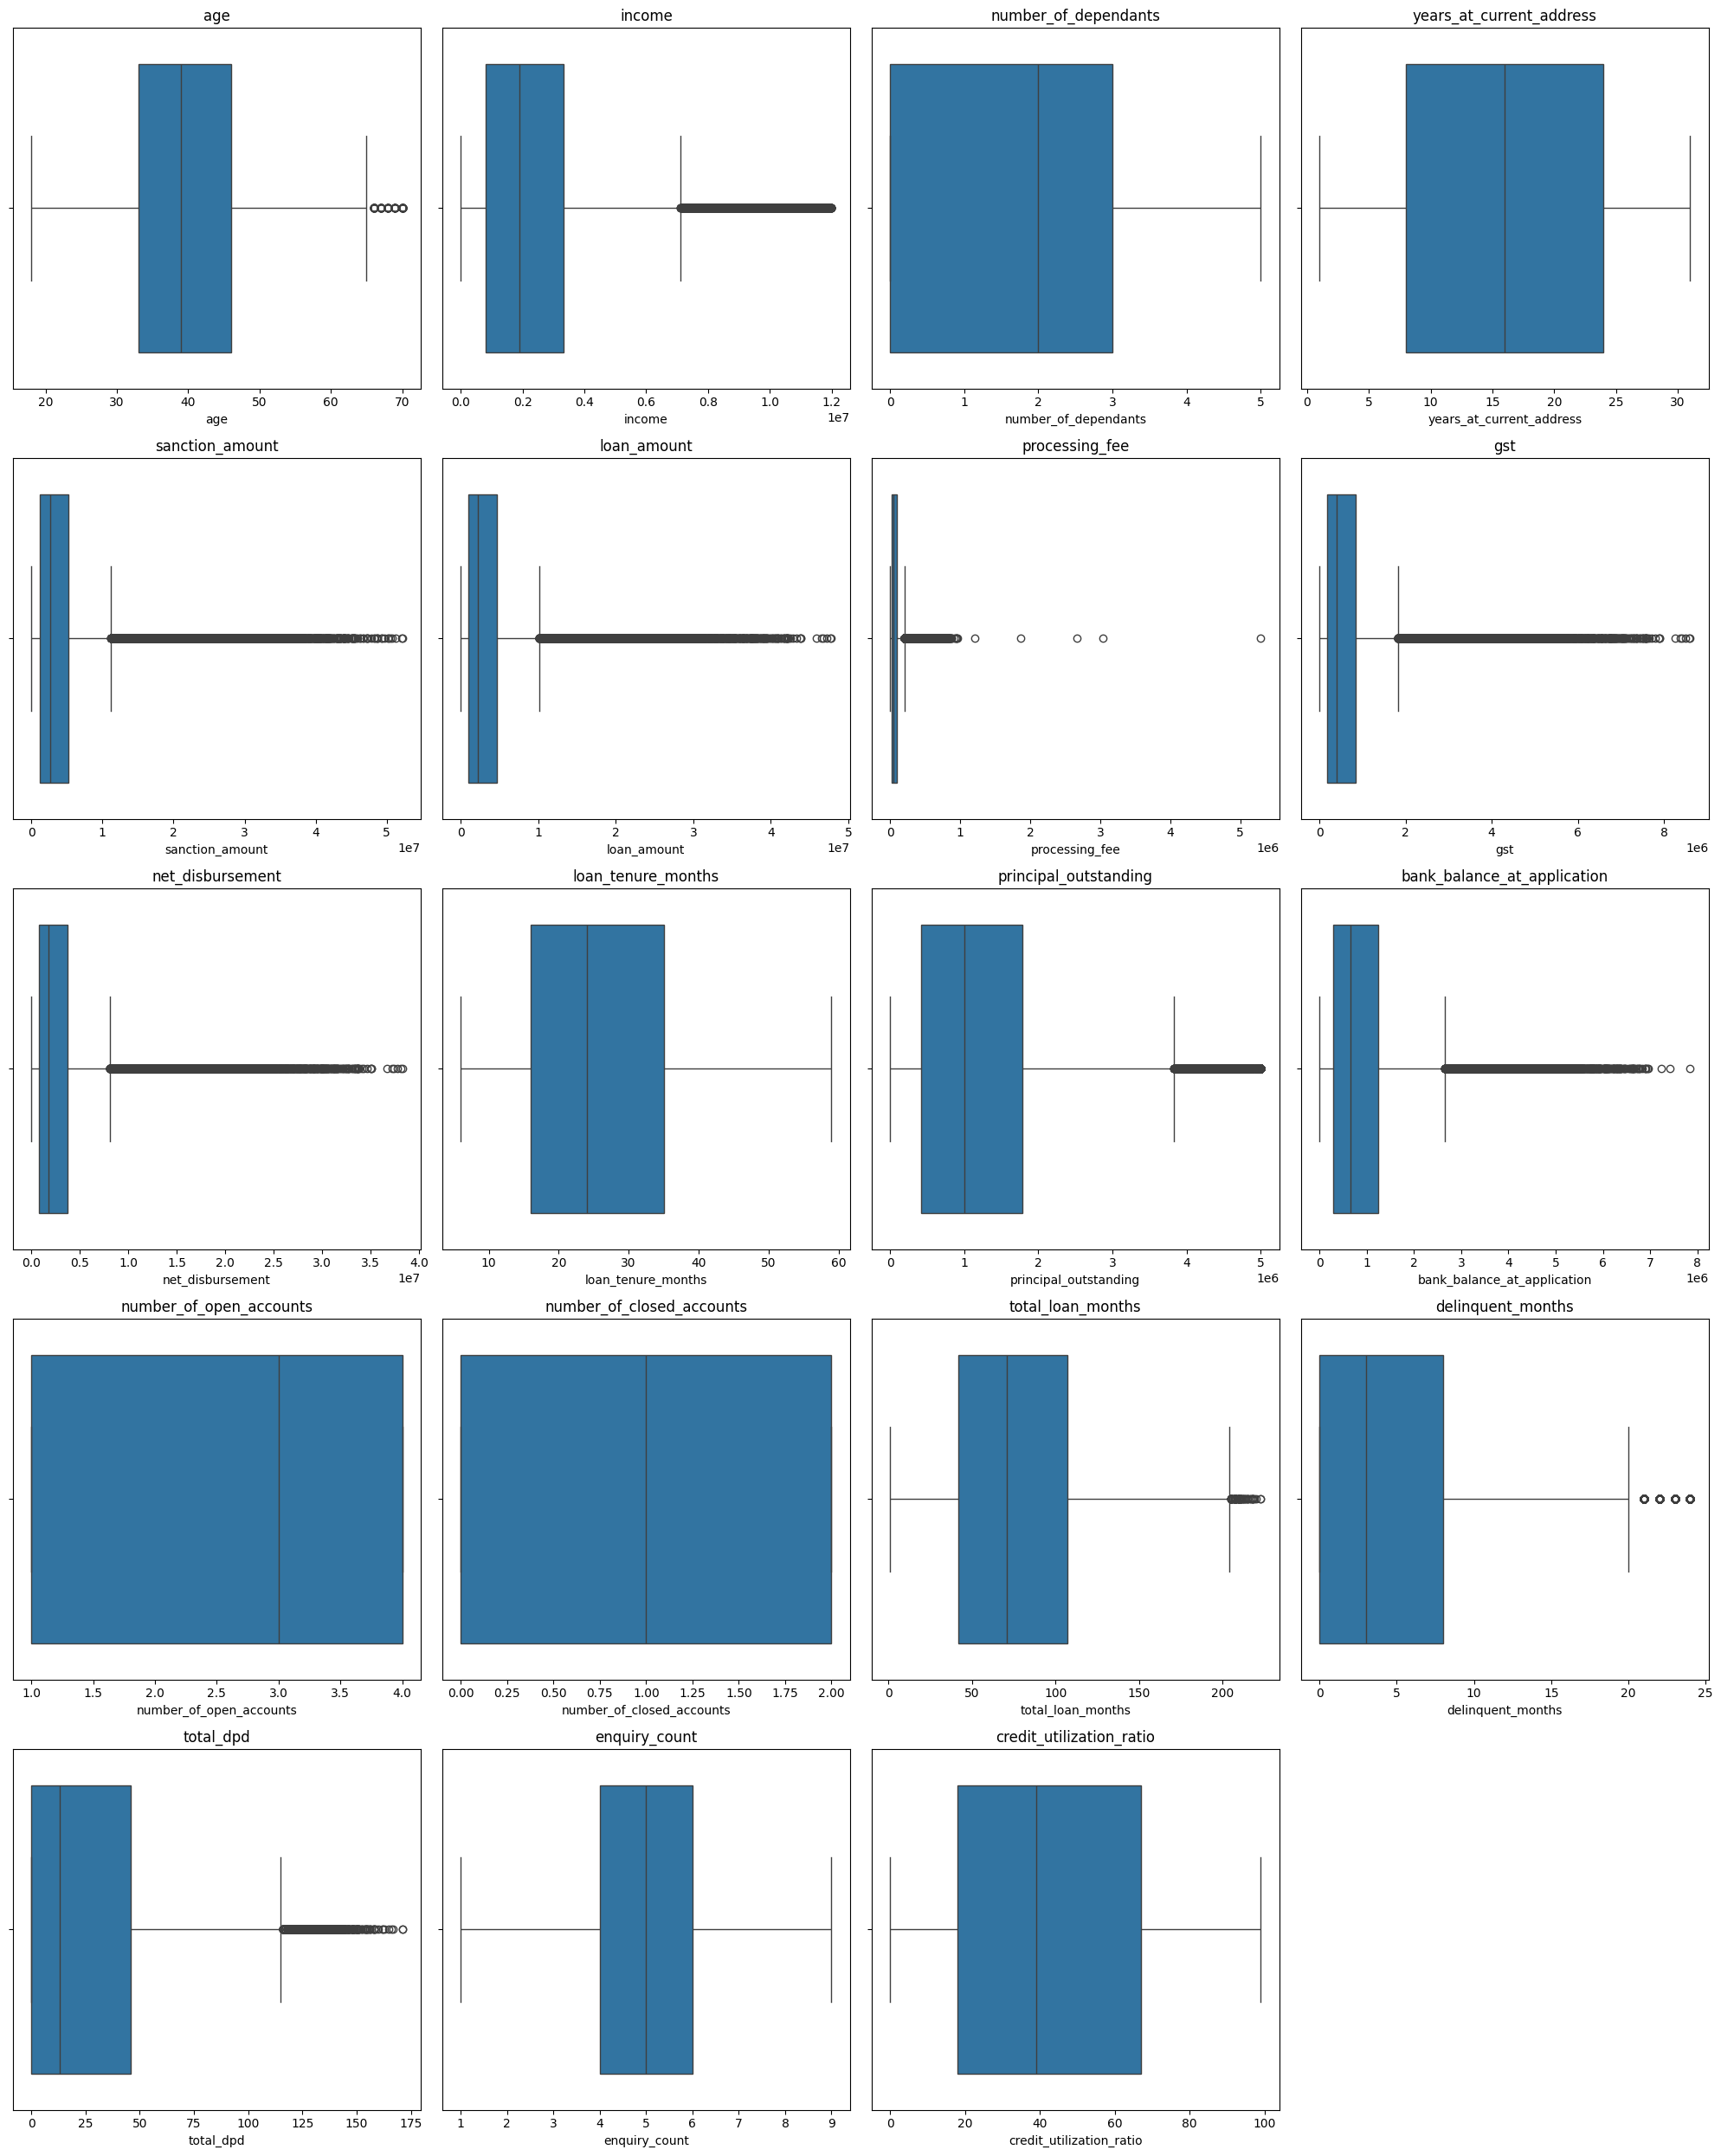

In [20]:
# box plot to visualise outliers
num_plots = len(columns_continuous)
num_cols = 4  # Number of plots per row
num_rows = (num_plots + num_cols - 1) // num_cols  # Calculate the number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, col in enumerate(columns_continuous):
    sns.boxplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(col)  # Set the title to the name of the variable

# If there are any empty plots (if the number of plots isn't a perfect multiple of num_cols), hide the axes
for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


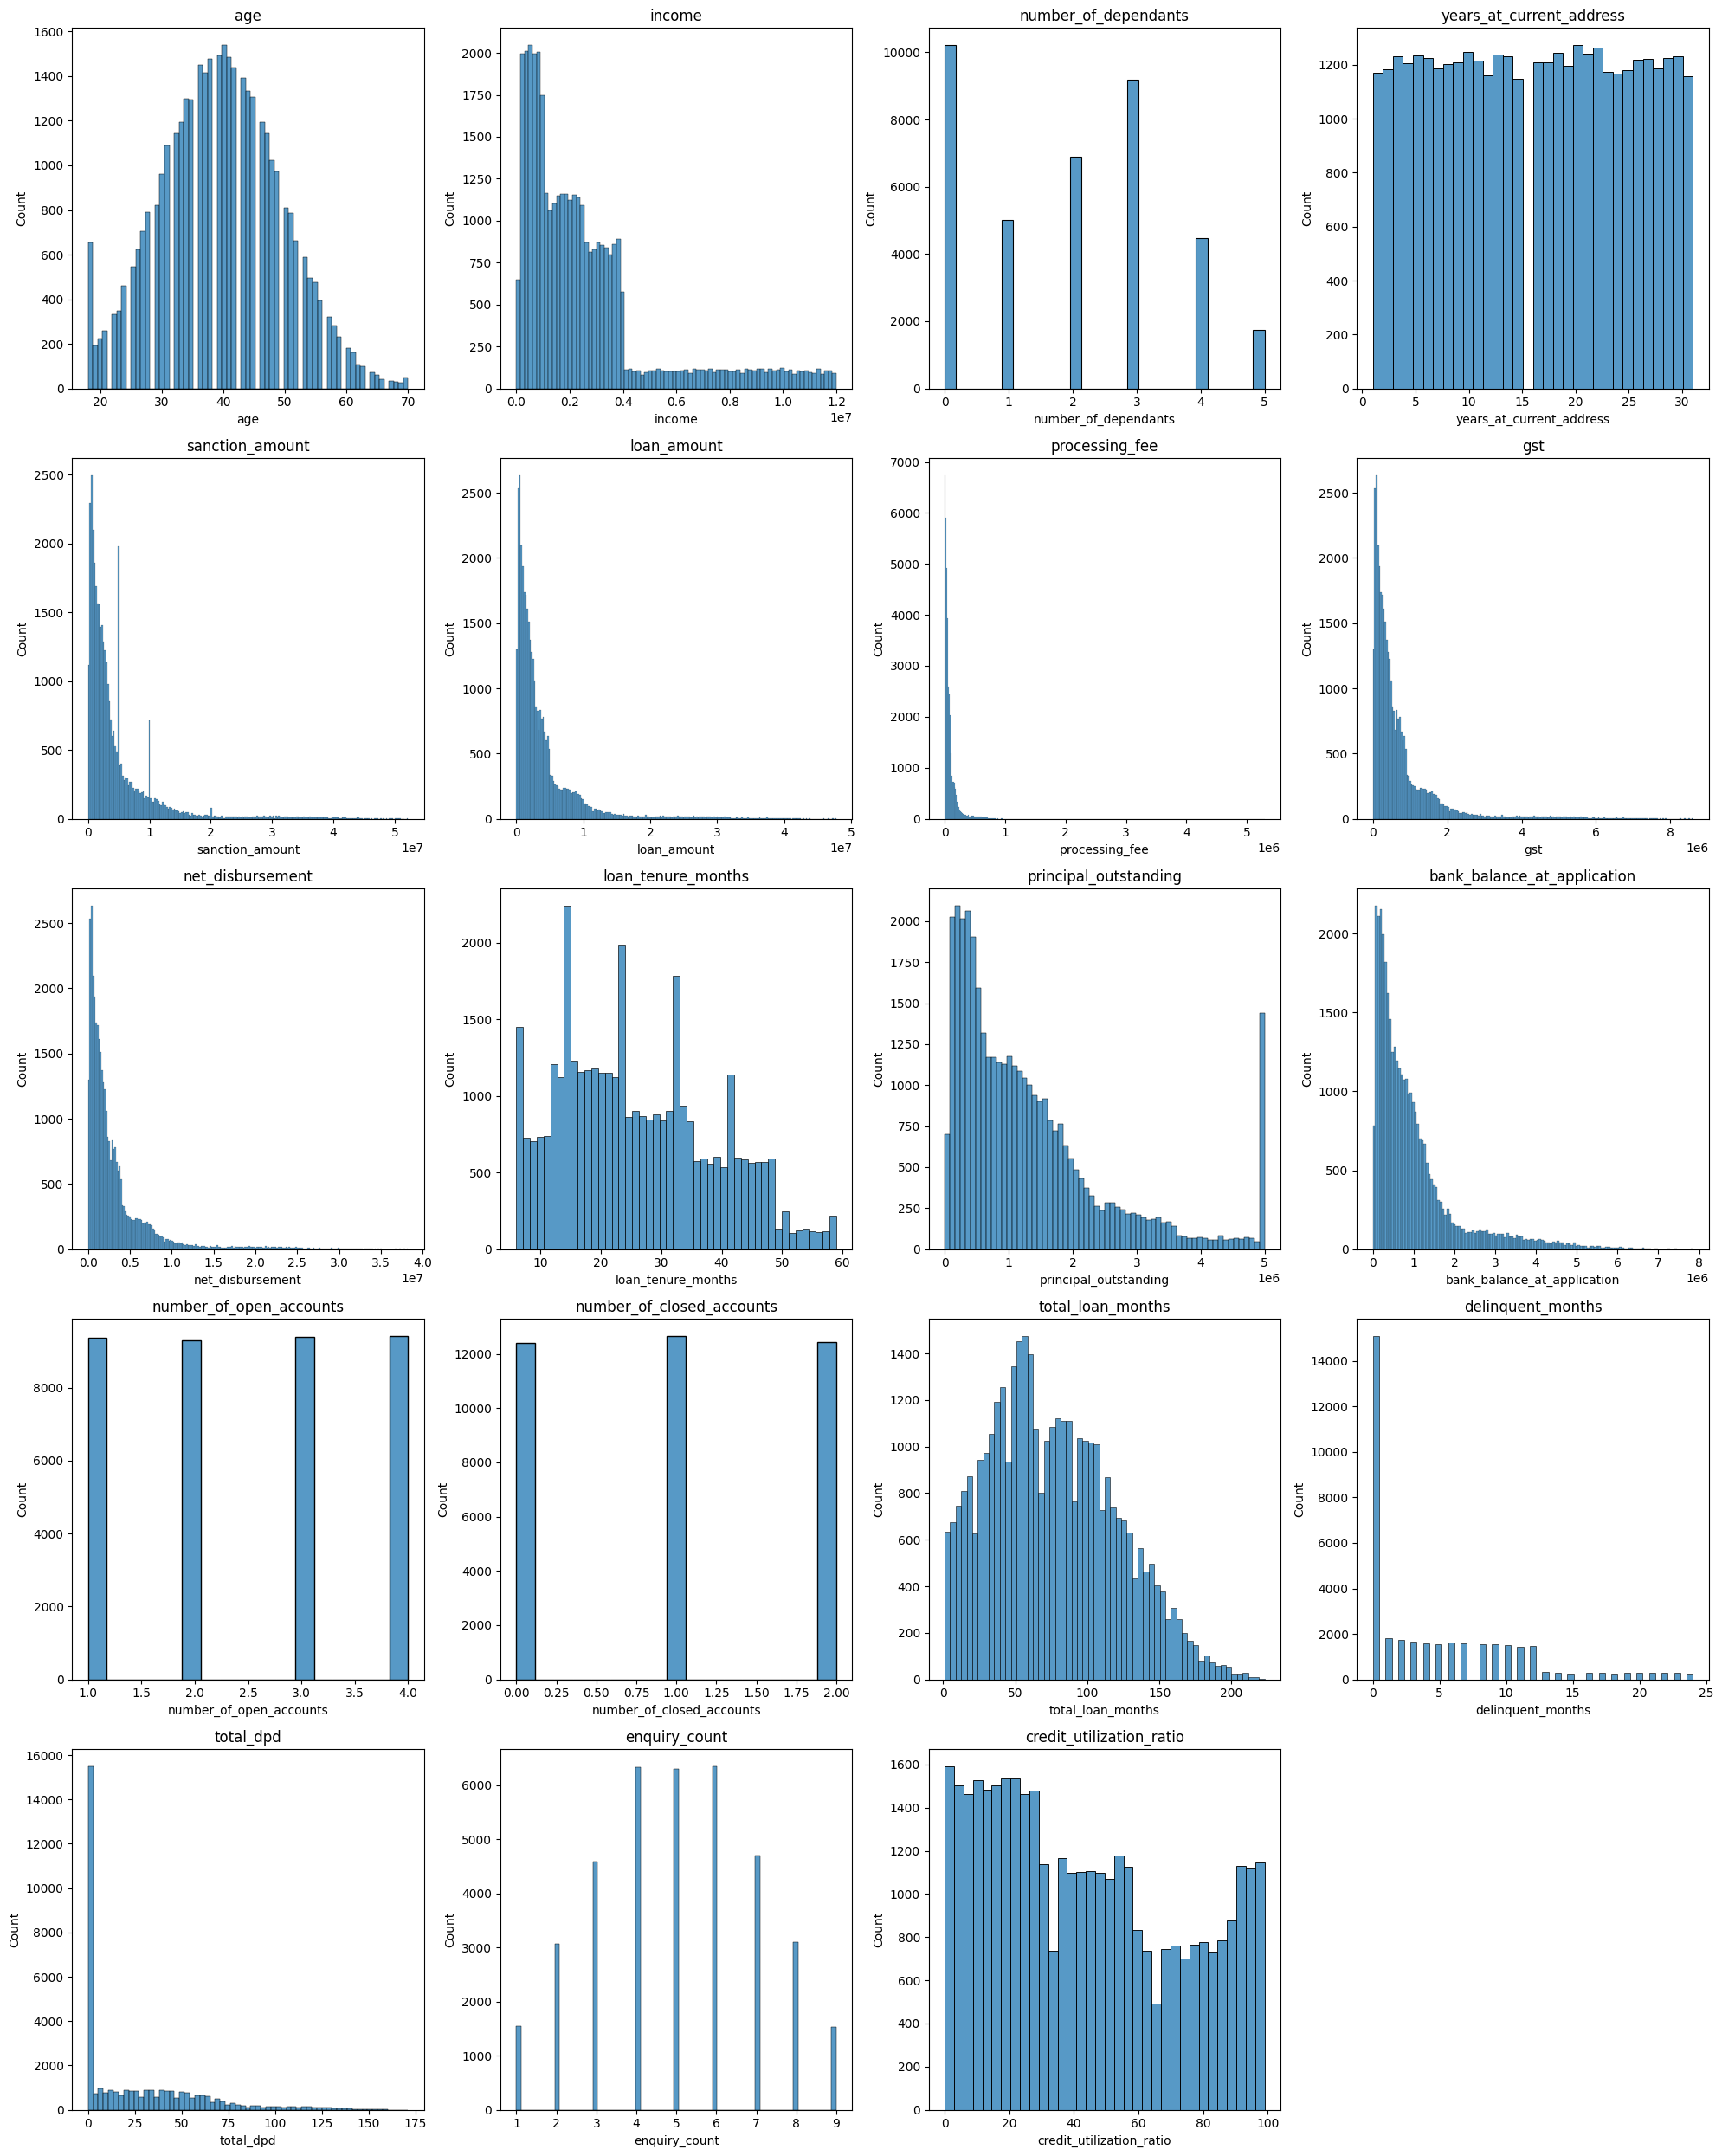

In [21]:
num_plots = len(columns_continuous)
num_cols = 4  # Number of plots per row
num_rows = (num_plots + num_cols - 1) // num_cols  # Calculate the number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, col in enumerate(columns_continuous):
    sns.histplot(df_train[col], ax=axes[i])
    axes[i].set_title(col)  # Set the title to the name of the variable

# If there are any empty plots (if the number of plots isn't a perfect multiple of num_cols), hide the axes
for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [22]:
# here in column processing fee is deeply left skewed. there might be a chance for outliers

df_train['processing_fee'].describe().astype(int)

count      37500
mean       80290
std       113128
min            0
25%        19220
50%        44600
75%        92420
max      5293543
Name: processing_fee, dtype: int64

In [23]:
#usually the processing fee should be less than 0.3% 

df_train[(df_train.processing_fee/df_train.loan_amount)>0.03][['loan_amount','processing_fee']].astype(int)

,loan_amount,processing_fee
23981,2234000,2669791
28174,966000,1214492
47089,1738000,1858964
29305,2616000,3036378
9898,3626000,5293543


In [24]:
df_train_1= df_train[(df_train.processing_fee/df_train.loan_amount)<0.03].copy()
df_train_1.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,31-10-2020,11-11-2020,4,2,152,20,118,4,36,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,22-10-2022,27-10-2022,3,1,160,10,62,5,5,0
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,...,04-12-2023,29-12-2023,1,1,54,12,67,4,0,0


In [25]:
df_train_1.shape

(37488, 33)

In [26]:
df_test= df_test[(df_test.processing_fee/df_test.loan_amount)<0.03].copy()
df_test.shape

(12497, 33)

In [27]:
# there are 2 other rules for business validation 
# rule1: gst should not be more than loan amount
# rule2: net embursement amount should not be higher than loan amount

df_train_1[(df_train_1.gst/df_train_1.loan_amount)>0.2].shape

(0, 33)

In [28]:
df_train_1[(df_train_1.net_disbursement > df_train_1.loan_amount)].shape 
# 2 rules are satisfied with the dataset

(0, 33)

In [29]:
columns_categorical

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type',
 'default']

In [30]:
for col in columns_categorical:
    print(col,'-->', df_train_1[col].unique().tolist())

gender --> ['M', 'F']
marital_status --> ['Married', 'Single']
employment_status --> ['Self-Employed', 'Salaried']
residence_type --> ['Owned', 'Mortgage', 'Rented']
city --> ['Hyderabad', 'Mumbai', 'Chennai', 'Bangalore', 'Pune', 'Kolkata', 'Ahmedabad', 'Delhi', 'Lucknow', 'Jaipur']
state --> ['Telangana', 'Maharashtra', 'Tamil Nadu', 'Karnataka', 'West Bengal', 'Gujarat', 'Delhi', 'Uttar Pradesh', 'Rajasthan']
zipcode --> [500001, 400001, 600001, 560001, 411001, 700001, 380001, 110001, 226001, 302001]
loan_purpose --> ['Home', 'Education', 'Personal', 'Auto', 'Personaal']
loan_type --> ['Secured', 'Unsecured']
default --> [0, 1]


In [31]:
# fixing the error in loan purpose column in both train & test dataset

df_train_1['loan_purpose']= df_train_1.loan_purpose.replace('Personaal', 'Personal')
df_train_1.loan_purpose.unique()

<ArrowStringArray>
['Home', 'Education', 'Personal', 'Auto']
Length: 4, dtype: str

In [32]:
df_test['loan_purpose']= df_test.loan_purpose.replace('Personaal','Personal')
df_test.loan_purpose.unique()

<ArrowStringArray>
['Home', 'Education', 'Auto', 'Personal']
Length: 4, dtype: str

In [33]:
# exploratory data analysis

In [34]:
columns_continuous

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio']

In [35]:
df_train_1.groupby('default')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,34265.0,39.767693,9.880235,18.0,33.0,40.0,46.0,70.0
1,3223.0,37.124729,9.290168,18.0,31.0,37.0,44.0,70.0


In [36]:
#both default and not default have same min max ages
# standard deviation also similar to each other
# average age of default is lesser than non default 

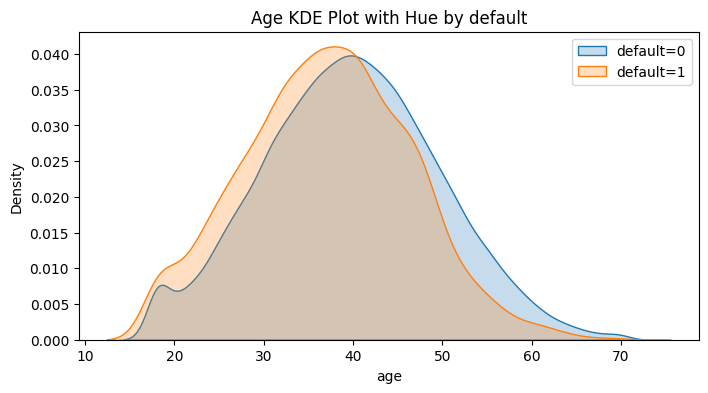

In [37]:
plt.figure(figsize=(8,4))
sns.kdeplot(df_train_1['age'][df_train_1['default']== 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['age'][df_train_1['default']== 1], fill=True, label='default=1')
plt.title(f"Age KDE Plot with Hue by default")
plt.legend()
plt.show()

In [38]:
# default group is slightly right side shifted, it indicates younger people are more likely to default

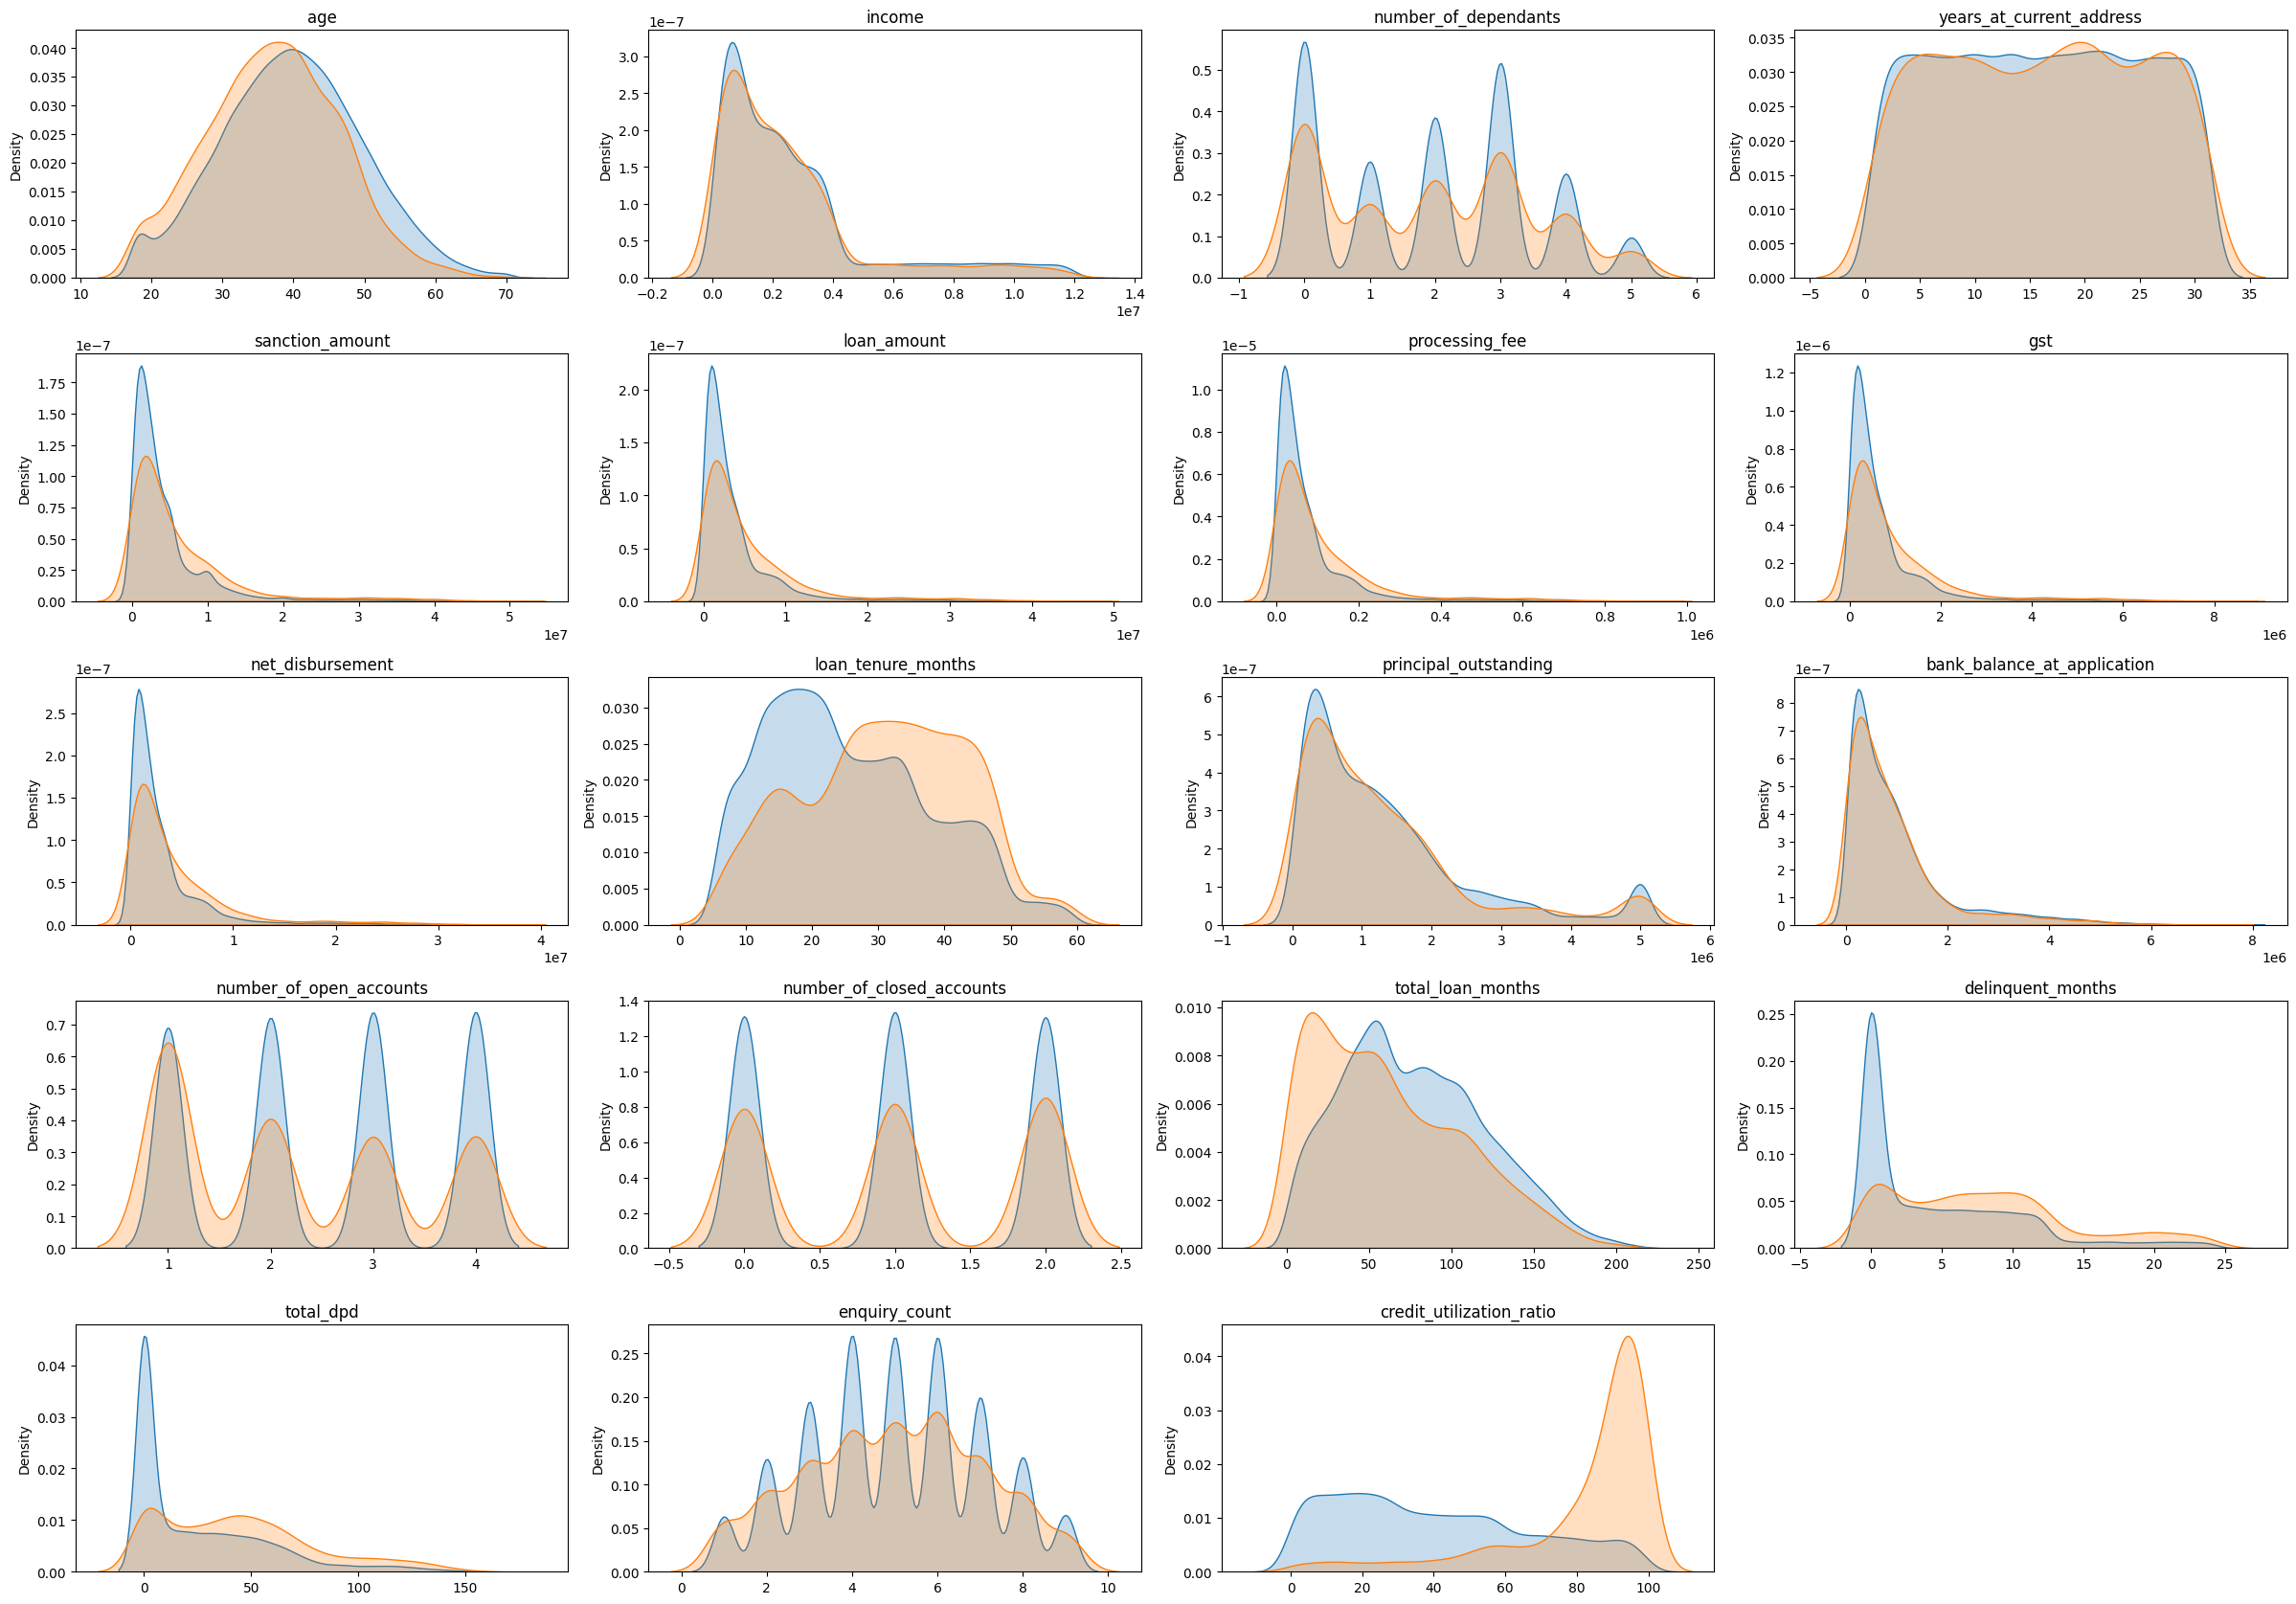

In [39]:
plt.figure(figsize=(24, 20))  # Width, height in inches

for i, col in enumerate(columns_continuous):
    plt.subplot(6, 4, i+1)  # 1 row, 4 columns, ith subplot
    sns.kdeplot(df_train_1[col][df_train_1['default']==0], fill=True, label='default=0')
    sns.kdeplot(df_train_1[col][df_train_1['default']==1], fill=True, label='default=1')
    plt.title(col)        
    plt.xlabel('')
    
plt.tight_layout()
plt.show()

In [40]:
# loan tenure months, delinquent months, total dpd, credit utilisation ratio. these 4 columns showing some pattern. these 4 looks like a strong predictors
# in remaining columns distribution isn't showing any pattern.
# loan amount, and income isn't showing any pattern. maybe if we combine these 2 rows and checking loan to income ratio that maybe will show any pattern. we'll explore that later

In [41]:
# feature engineering & feature selection

In [42]:
#loan to income ratio

In [43]:
df_train_1[['loan_amount', 'income']].head()

,loan_amount,income
12746,23442000,11327000
32495,1149000,715000
43675,11296000,3195000
9040,1695000,1500000
13077,905000,1817000


In [44]:
df_train_1['loan_to_income']= (df_train_1['loan_amount'] / df_train_1['income']).round(2)
df_train_1.loan_to_income.describe().round(2)

count    37488.00
mean         1.56
std          0.97
min          0.30
25%          0.77
50%          1.16
75%          2.46
max          4.57
Name: loan_to_income, dtype: float64

In [45]:
df_test['loan_to_income']= (df_test['loan_amount'] / df_test['income']).round(2)

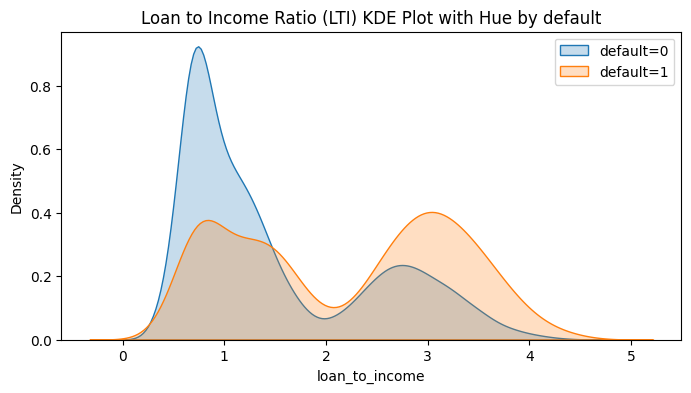

In [46]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1['loan_to_income'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['loan_to_income'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Loan to Income Ratio (LTI) KDE Plot with Hue by default")
plt.legend()
plt.show()

In [47]:
# blue group prepresent low loan to income ratio & orange represents high loan to income ratio.
# high loan to income ratio has more default

In [48]:
# generate delinquency ratio

In [49]:
df_train_1['delinquency_ratio']= (df_train_1['delinquent_months'] *100 / df_train_1['total_loan_months']).round(1)
df_test['delinquency_ratio']= (df_test['delinquent_months'] *100 / df_test['total_loan_months']).round(1)

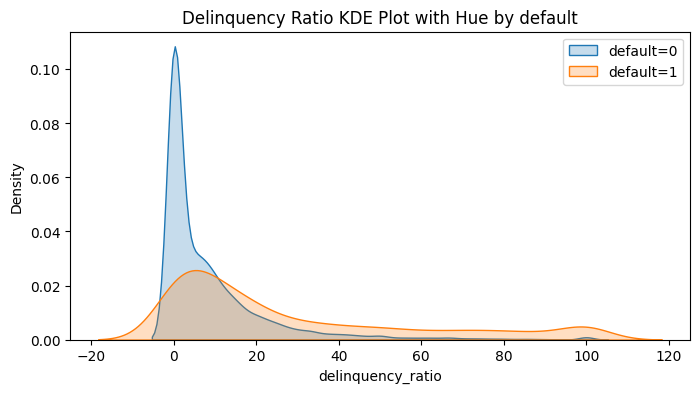

In [50]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1['delinquency_ratio'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['delinquency_ratio'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Delinquency Ratio KDE Plot with Hue by default")
plt.legend()
plt.show()

In [51]:
# some higher delinquency ratio indicating default

In [52]:
# generating dpd per delinquency

In [53]:
df_train_1['avg_dpd_per_delinquency']= np.where(df_train_1['delinquent_months'] !=0, (df_train_1['total_dpd'] / df_train_1['delinquent_months']).round(1),0)
df_test['avg_dpd_per_delinquency']= np.where(df_test['delinquent_months'] !=0, (df_test['total_dpd'] / df_test['delinquent_months']).round(1),0)

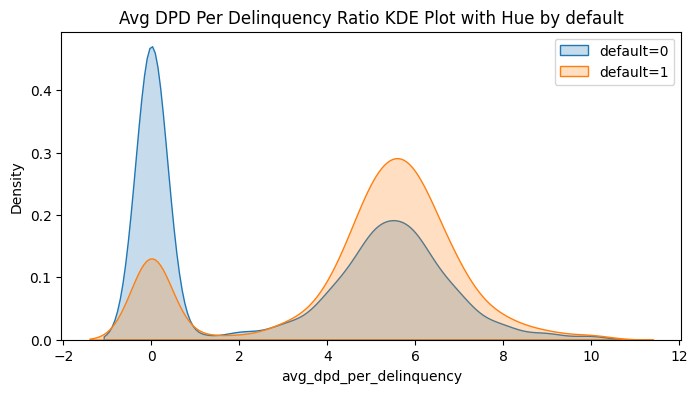

In [54]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1['avg_dpd_per_delinquency'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['avg_dpd_per_delinquency'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Avg DPD Per Delinquency Ratio KDE Plot with Hue by default")
plt.legend()
plt.show()

In [55]:
# this shows where dpd per delinquency ratio is high, there might be a chance to default. this feature will influence the model prediction.

In [56]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='str')

In [57]:
# dropping unwanted columns from the dataset

df_train_3 = df_train_1.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd', 'cust_id', 'loan_id'], axis=1)

df_test = df_test.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd', 'cust_id', 'loan_id'], axis=1)

In [58]:
df_train_3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='str')

In [59]:
df_train_3['default'].value_counts()

default
0    34265
1     3223
Name: count, dtype: int64

In [60]:
cols_to_scale= df_train_3.select_dtypes(['int64', 'float64']).columns
cols_to_scale= df_train_3[cols_to_scale].drop('default', axis=1)
cols_to_scale.columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='str')

In [61]:
# vif to measure multicolinearity

In [62]:
cols_to_scale= cols_to_scale.columns.tolist()

In [63]:
X_train= df_train_3.drop('default', axis=1)
y_train= df_train_3['default']

from sklearn.preprocessing import MinMaxScaler

scaler= MinMaxScaler()

X_train[cols_to_scale]= scaler.fit_transform(X_train[cols_to_scale])
X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.00000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000
mean,0.414240,0.388903,0.499918,0.523517,0.088840,0.082513,0.082513,0.082513,0.376631,0.261615,0.123550,0.500925,0.50056,0.501077,0.438653,0.294312,0.103299,0.328391
std,0.189590,0.307182,0.297364,0.286491,0.120117,0.112480,0.112480,0.112480,0.234860,0.244461,0.133275,0.373040,0.40701,0.253666,0.296902,0.228030,0.172985,0.290663
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288462,0.000000,0.233333,0.325424,0.020555,0.018963,0.018963,0.018963,0.188679,0.077988,0.034205,0.000000,0.00000,0.375000,0.181818,0.110070,0.000000,0.000000
50%,0.403846,0.400000,0.500000,0.491525,0.049364,0.045516,0.045516,0.045516,0.339623,0.193870,0.082515,0.666667,0.50000,0.500000,0.393939,0.201405,0.037000,0.430000
75%,0.538462,0.600000,0.766667,0.762712,0.098027,0.095555,0.095555,0.095555,0.547170,0.352418,0.155192,1.000000,1.00000,0.625000,0.676768,0.505855,0.129000,0.572500
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [64]:
X_test= df_test.drop('default', axis=1)
y_test= df_test['default']

X_test[cols_to_scale]= scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000
mean,0.415001,0.384892,0.502697,0.525015,0.089218,0.082800,0.082800,0.082800,0.375092,0.264632,0.124944,0.497293,0.500440,0.501470,0.436038,0.293038,0.106074,0.333844
std,0.188773,0.306871,0.298103,0.286179,0.120844,0.112877,0.112877,0.112877,0.233792,0.245290,0.134708,0.372576,0.407226,0.253618,0.295418,0.226176,0.173081,0.289680
min,0.000000,0.000000,0.000000,0.000000,-0.000019,-0.000126,-0.000126,-0.000126,0.000000,0.000163,0.000668,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288462,0.000000,0.233333,0.325424,0.020958,0.019387,0.019387,0.019387,0.188679,0.079715,0.034167,0.000000,0.000000,0.375000,0.181818,0.112412,0.000000,0.000000
50%,0.423077,0.400000,0.500000,0.510169,0.050189,0.046249,0.046249,0.046249,0.339623,0.198239,0.084024,0.333333,0.500000,0.500000,0.393939,0.201405,0.042000,0.440000
75%,0.538462,0.600000,0.766667,0.762712,0.097422,0.094927,0.094927,0.094927,0.547170,0.356914,0.157792,0.666667,1.000000,0.625000,0.676768,0.498829,0.134000,0.580000
max,1.000000,1.000000,1.000000,1.000000,0.981249,0.963717,0.963717,0.963717,1.000000,1.000000,0.939154,1.000000,1.000000,1.000000,1.000000,1.004684,1.000000,1.000000


In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df= pd.DataFrame()
    vif_df['Column']= data.columns
    vif_df['VIF']= [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [66]:
calculate_vif(X_train[cols_to_scale])

c:\Users\MS Computers\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
0,age,5.700665
1,number_of_dependants,2.730312
2,years_at_current_address,3.422577
3,zipcode,3.797524
4,sanction_amount,101.086559
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.180519
9,principal_outstanding,16.326471


In [67]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement','principal_outstanding']


X_train_1 = X_train.drop(features_to_drop_vif, axis='columns')
numeric_columns = X_train_1.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='str')

In [68]:
calculate_vif(X_train_1[numeric_columns])

,Column,VIF
0,age,5.429171
1,number_of_dependants,2.726774
2,years_at_current_address,3.403712
3,zipcode,3.777885
4,loan_tenure_months,6.018724
5,bank_balance_at_application,1.804693
6,number_of_open_accounts,4.353487
7,number_of_closed_accounts,2.372449
8,enquiry_count,6.384110
9,credit_utilization_ratio,2.919822


In [69]:
vif_df = calculate_vif(X_train_1[numeric_columns])
vif_df

,Column,VIF
0,age,5.429171
1,number_of_dependants,2.726774
2,years_at_current_address,3.403712
3,zipcode,3.777885
4,loan_tenure_months,6.018724
5,bank_balance_at_application,1.804693
6,number_of_open_accounts,4.353487
7,number_of_closed_accounts,2.372449
8,enquiry_count,6.384110
9,credit_utilization_ratio,2.919822


In [70]:
selected_numeric_features_vif = vif_df.Column.values
selected_numeric_features_vif

<ArrowStringArray>
[                        'age',        'number_of_dependants',
    'years_at_current_address',                     'zipcode',
          'loan_tenure_months', 'bank_balance_at_application',
     'number_of_open_accounts',   'number_of_closed_accounts',
               'enquiry_count',    'credit_utilization_ratio',
              'loan_to_income',           'delinquency_ratio',
     'avg_dpd_per_delinquency']
Length: 13, dtype: str

In [71]:
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='str')

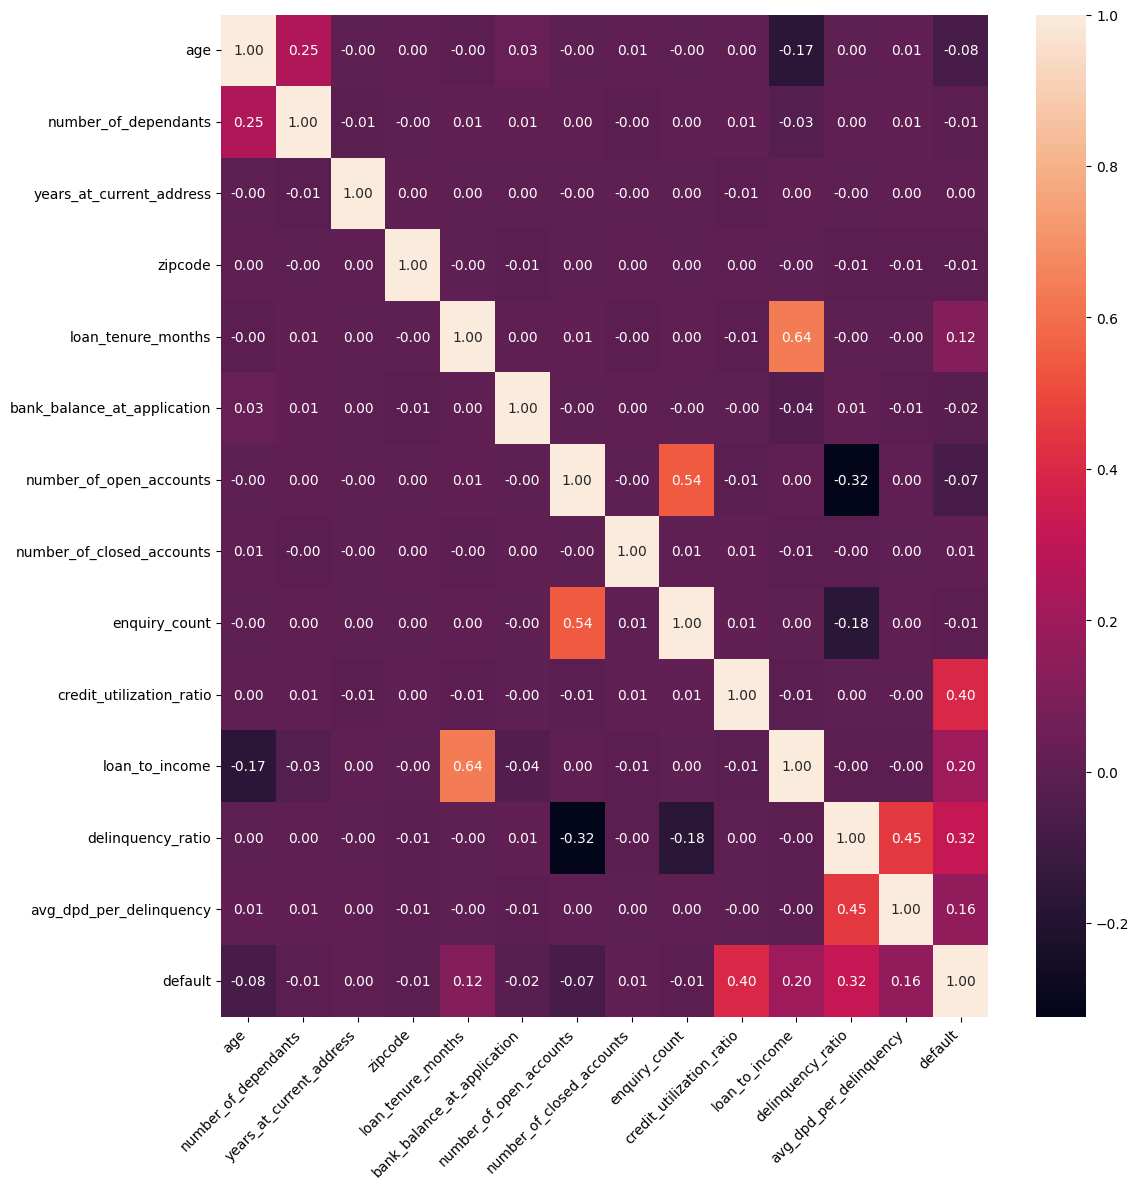

In [72]:
plt.figure(figsize=(12,12))
cm = df_train_3[numeric_columns.append(pd.Index(['default']))].corr()
sns.heatmap(cm, annot=True, fmt='0.2f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [73]:
# feature selection: categorical features

In [74]:
def calculate_woe_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad']=grouped['total']-grouped['good']
    
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad
    grouped['woe'] = np.log(grouped['good_pct']/ grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct'] -grouped['bad_pct'])*grouped['woe']
    
    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    
    total_iv = grouped['iv'].sum()
    
    return grouped, total_iv

grouped, total_iv = calculate_woe_iv(pd.concat([X_train_1, y_train],axis=1), 'loan_purpose', 'default')
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,
Auto,7447,327,7120,0.101458,0.207792,-0.716891,0.076230
Education,5620,559,5061,0.173441,0.147702,0.160642,0.004135
Home,11304,1734,9570,0.538008,0.279294,0.655609,0.169616
Personal,13117,603,12514,0.187093,0.365212,-0.668874,0.119140


In [75]:
iv_values = {}
categorical_override = ['zipcode']

for feature in X_train_1.columns:
    if pd.api.types.is_numeric_dtype(X_train_1[feature]) and feature not in categorical_override:
        X_binned = pd.cut(X_train_1[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_binned, y_train], axis=1), feature, 'default')
    else:
        _, iv = calculate_woe_iv(pd.concat([X_train_1, y_train], axis=1), feature, 'default')
    iv_values[feature] = iv

iv_values

{'age': np.float64(0.0890689462679479),
 'gender': np.float64(0.00047449502170914947),
 'marital_status': np.float64(0.001129766845390142),
 'employment_status': np.float64(0.003953046301722585),
 'number_of_dependants': np.float64(0.0019380899135053508),
 'residence_type': np.float64(0.246745268718145),
 'years_at_current_address': np.float64(0.0020800513608156363),
 'city': np.float64(0.0019059578709781529),
 'state': np.float64(0.0019005589806779287),
 'zipcode': np.float64(0.0019059578709781525),
 'loan_purpose': np.float64(0.3691197842282755),
 'loan_type': np.float64(0.16319324904149224),
 'loan_tenure_months': np.float64(0.21893515090196278),
 'bank_balance_at_application': np.float64(0.0063187993277516365),
 'number_of_open_accounts': np.float64(0.08463134083005877),
 'number_of_closed_accounts': np.float64(0.0011964272592421567),
 'enquiry_count': np.float64(0.007864214085342608),
 'credit_utilization_ratio': np.float64(2.352965568168245),
 'loan_to_income': np.float64(0.47641

In [76]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.353
19,delinquency_ratio,0.717
18,loan_to_income,0.476
20,avg_dpd_per_delinquency,0.402
10,loan_purpose,0.369
5,residence_type,0.247
12,loan_tenure_months,0.219
11,loan_type,0.163
0,age,0.089
14,number_of_open_accounts,0.085


In [77]:
selected_features_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_features_iv

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

In [78]:
# feature encoding

In [79]:
X_train_reduced= X_train_1[selected_features_iv]
X_test_reduced= X_test[selected_features_iv]

In [80]:
X_train_encoded= pd.get_dummies(X_train_reduced, drop_first=True)
X_train_encoded.head()

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
12746,0.788,0.415,1.000,0.364,0.415,0.132,0.590,True,False,False,True,False,False
32495,0.500,0.830,0.667,0.051,0.307,0.062,0.620,True,False,True,False,False,False
43675,0.385,0.491,0.000,0.000,0.759,0.222,0.560,False,False,False,True,False,False
9040,0.462,0.642,0.667,0.879,0.194,0.000,0.000,False,False,True,False,False,False
13077,0.769,0.170,0.000,0.717,0.047,0.000,0.000,True,False,False,False,True,True


In [81]:
X_test_encoded= pd.get_dummies(X_test_reduced, drop_first=True)
X_test_encoded.head()

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
19205,0.346,0.755,0.333,0.990,0.550,0.000,0.000,True,False,False,True,False,False
15514,0.481,0.226,1.000,0.323,0.220,0.000,0.000,True,False,True,False,False,False
30367,0.231,0.547,0.667,0.828,0.180,0.000,0.000,True,False,False,False,False,False
35347,0.365,0.755,1.000,0.485,0.571,0.024,0.700,True,False,False,True,False,False
41814,0.577,0.717,0.667,0.980,0.407,0.107,0.640,False,False,False,True,False,False


In [82]:
# model training

In [83]:
# attempt 1
# logistics regression, random forest, xbg
# without handling class imbalance

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model= LogisticRegression().fit(X_train_encoded, y_train)
y_pred= model.predict(X_test_encoded)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.72      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



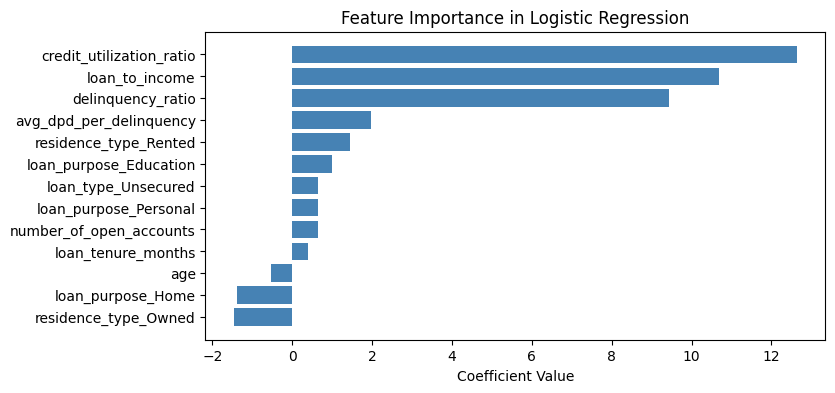

In [85]:
# feature importance

feature_importance= model.coef_[0]

coef_df= pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])
coef_df= coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [86]:
# random forest classification model

from sklearn.ensemble import RandomForestClassifier

model= RandomForestClassifier().fit(X_train_encoded, y_train)

y_pred= model.predict(X_test_encoded)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.86      0.71      0.78      1074

    accuracy                           0.97     12497
   macro avg       0.92      0.85      0.88     12497
weighted avg       0.96      0.97      0.96     12497



In [87]:
from xgboost import XGBClassifier

model= XGBClassifier().fit(X_train_encoded, y_train)

y_pred= model.predict(X_test_encoded)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.82      0.76      0.79      1074

    accuracy                           0.97     12497
   macro avg       0.90      0.87      0.89     12497
weighted avg       0.96      0.97      0.96     12497



In [88]:
# since there is no difference between these model. now i choose random search cv for logistics regression

In [89]:
from sklearn.model_selection import RandomizedSearchCV

param_dist={
    'C': np.logspace(-4, 4, 20), 'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']
}

log_reg= LogisticRegression(max_iter=10000)

random_search= RandomizedSearchCV(
    estimator= log_reg,
    param_distributions= param_dist,
    n_iter=50,
    scoring= 'f1',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_encoded, y_train)

print('Best parameters :', random_search.best_params_)
print('Best score :', random_search.best_score_)

best_model= random_search.best_estimator_
y_pred= best_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters : {'solver': 'liblinear', 'C': np.float64(1438.44988828766)}
Best score : 0.7578820896729832
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11423
           1       0.83      0.74      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.86      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [90]:
# randomised search cv for xgboost

param_dist= {
    'n_estimators': [100, 150, 200, 250, 300],
        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
        'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'scale_pos_weight': [1, 2, 3, 5, 7, 10],
        'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # L1 regularization term
        'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

xgb= XGBClassifier()

random_search= RandomizedSearchCV(
    estimator= xgb, param_distributions= param_dist, n_iter=100, scoring='f1', cv=3, verbose=1, n_jobs=-1, random_state=42
)

random_search.fit(X_train_encoded, y_train)

print('Best parameters :', random_search.best_params_)
print('Best score :', random_search.best_score_)

best_model= random_search.best_estimator_
y_pred= best_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best parameters : {'subsample': 0.8, 'scale_pos_weight': 2, 'reg_lambda': 1.0, 'reg_alpha': 5.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best score : 0.7883672970285227
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.77      0.84      0.80      1074

    accuracy                           0.96     12497
   macro avg       0.88      0.91      0.89     12497
weighted avg       0.97      0.96      0.96     12497



In [91]:
# logistics regression & Xgb 
# handling class imbalance using undersampling

In [92]:
from imblearn.under_sampling import RandomUnderSampler

rus= RandomUnderSampler(random_state=42)
X_train_res, y_train_res= rus.fit_resample(X_train_encoded, y_train)

y_train_res.value_counts()

default
0    3223
1    3223
Name: count, dtype: int64

In [93]:
model= LogisticRegression().fit(X_train_res, y_train_res)

y_pred= model.predict(X_test_encoded)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.51      0.96      0.67      1074

    accuracy                           0.92     12497
   macro avg       0.75      0.93      0.81     12497
weighted avg       0.95      0.92      0.93     12497



In [94]:
model = XGBClassifier(**random_search.best_params_)
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.51      0.98      0.67      1074

    accuracy                           0.92     12497
   macro avg       0.75      0.95      0.81     12497
weighted avg       0.96      0.92      0.93     12497



In [95]:
# handling class imbalance using smote tomek
# logistics regression

In [96]:
from imblearn.combine import SMOTETomek

smt= SMOTETomek(random_state=42)
X_train_smt, y_train_smt= smt.fit_resample(X_train_encoded, y_train)

y_train_smt.value_counts()

default
0    34195
1    34195
Name: count, dtype: int64

In [97]:
model= LogisticRegression().fit(X_train_smt, y_train_smt)

y_pred= model.predict(X_test_encoded)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.55      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [98]:
# parameter tuning using optuna

In [99]:
import optuna
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

In [100]:
def objective(trial):
    param = {
            'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Logarithmically spaced values
            'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']),  # Solvers
            'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Logarithmically spaced values for tolerance
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']) }

    model= LogisticRegression(**param, max_iter=10000)

    f1_scorer= make_scorer(f1_score, average= 'macro') 
    scores= cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)

    return np.mean(scores)

study_logistic= optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50) 


[I 2026-07-09 19:01:10,205] A new study created in memory with name: no-name-798ef42f-1cf9-471d-9729-5bc017e666c0


[I 2026-07-09 19:01:11,742] Trial 0 finished with value: 0.9456207881200721 and parameters: {'C': 93.70145697435981, 'solver': 'liblinear', 'tol': 0.0008886790047302126, 'class_weight': None}. Best is trial 0 with value: 0.9456207881200721.
[I 2026-07-09 19:01:12,754] Trial 1 finished with value: 0.9433754255738437 and parameters: {'C': 38.96096656308607, 'solver': 'liblinear', 'tol': 0.09586151108102417, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9456207881200721.
[I 2026-07-09 19:01:14,417] Trial 2 finished with value: 0.9399184018173411 and parameters: {'C': 0.07061639103353792, 'solver': 'saga', 'tol': 9.542741536636083e-05, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9456207881200721.
[I 2026-07-09 19:01:15,755] Trial 3 finished with value: 0.9416490783146036 and parameters: {'C': 0.1880963037592131, 'solver': 'liblinear', 'tol': 3.851139529708838e-05, 'class_weight': None}. Best is trial 0 with value: 0.9456207881200721.
[I 2026-07-09 19:01:17,270] 

In [101]:
print('best trail :')
trial= study_logistic.best_trial

print('f1-score {}'.format(trial.value))
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))


best_model_logistic= LogisticRegression(**study_logistic.best_params).fit(X_train_smt, y_train_smt)

y_pred= best_model_logistic.predict(X_test_encoded)

print(classification_report(y_test, y_pred))

best trail :
f1-score 0.9458675576137013
    C: 3.9824395621350868
    solver: liblinear
    tol: 3.2360423207650566e-05
    class_weight: balanced
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [102]:
# xgboost model
# handling class imbalance using smote tomek 
# parameter tuning using optuna

In [103]:
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'verbosity': 0,
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    model= XGBClassifier(**param)
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
        
    return np.mean(scores)


study_xgb= optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

[I 2026-07-09 19:02:19,531] A new study created in memory with name: no-name-32fefea9-3456-44bd-b2f6-29b207d58b2e
[I 2026-07-09 19:02:23,349] Trial 0 finished with value: 0.9611296358990042 and parameters: {'lambda': 0.004322042337237109, 'alpha': 0.030480220069814833, 'subsample': 0.88849324041949, 'colsample_bytree': 0.9778267977296362, 'max_depth': 5, 'eta': 0.2278072901440714, 'gamma': 8.628783449152806, 'scale_pos_weight': 4.985360812909613, 'min_child_weight': 4, 'max_delta_step': 0}. Best is trial 0 with value: 0.9611296358990042.
[I 2026-07-09 19:02:27,090] Trial 1 finished with value: 0.9617016715810474 and parameters: {'lambda': 0.2419212813263205, 'alpha': 0.01284149891776357, 'subsample': 0.6231520127474142, 'colsample_bytree': 0.5081015036161867, 'max_depth': 7, 'eta': 0.21982671877678178, 'gamma': 9.193973082623367, 'scale_pos_weight': 4.393938457315098, 'min_child_weight': 10, 'max_delta_step': 8}. Best is trial 1 with value: 0.9617016715810474.
[I 2026-07-09 19:02:31,63

In [104]:
print('best trial :')
trial= study_xgb.best_trial
print('f1-score {}'.format(trial.value))
print('params :')

for key, value in trial.params.items():
    print(' {}: {}'.format(key, value))

best_params= study_xgb.best_params
best_model_xgb= XGBClassifier(**best_params).fit(X_train_smt, y_train_smt)

y_pred= best_model_xgb.predict(X_test_encoded)

print(classification_report(y_test, y_pred))

best trial :
f1-score 0.975839161097032
params :
 lambda: 0.054434772333963447
 alpha: 0.6265239941407449
 subsample: 0.8595644505433873
 colsample_bytree: 0.8731986274448946
 max_depth: 9
 eta: 0.2856467622551881
 gamma: 0.6254467715960311
 scale_pos_weight: 1.441370746713484
 min_child_weight: 9
 max_delta_step: 3
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     11423
           1       0.73      0.83      0.77      1074

    accuracy                           0.96     12497
   macro avg       0.86      0.90      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [105]:
# model_evaluation: roc/auc

y_pred= best_model_logistic.predict(X_test_encoded)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [106]:
from sklearn.metrics import roc_curve, auc

propabilities= best_model_logistic.predict_proba(X_test_encoded)[:,1]

fpr, tpr, threshold= roc_curve(y_test, propabilities)

fpr[:5], tpr[:5], threshold[:5]

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.75426771e-05,
        8.75426771e-05]),
 array([0.        , 0.0009311 , 0.16108007, 0.16108007, 0.17690875]),
 array([       inf, 1.        , 0.99941645, 0.99940868, 0.9992822 ]))

In [107]:
area= auc(fpr, tpr)
area

0.9836776923163449

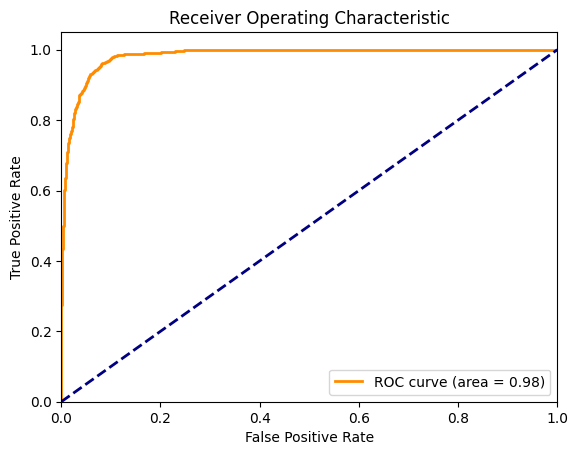

In [108]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [109]:
# model evaluation : rankordering, ks statistics, gini coeff

In [118]:
probabilities= best_model_logistic.predict_proba(X_test_encoded)[:,1]

df_eval= pd.DataFrame({
    'Default Truth': y_test,
    'Default Probabilities': probabilities
})

df_eval.head(3)

,Default Truth,Default Probabilities
19205,0,0.535
15514,0,0.000
30367,0,0.006


In [119]:
df_eval['Decile']= pd.qcut(df_eval['Default Probabilities'], 10, labels=False, duplicates='drop')
df_eval.head()

,Default Truth,Default Probabilities,Decile
19205,0,0.535,8
15514,0,0.000,2
30367,0,0.006,6
35347,0,0.007,6
41814,1,0.922,9


In [120]:
df_eval[df_eval.Decile==8]['Default Probabilities'].describe()

count   1250.000
mean       0.487
std        0.181
min        0.217
25%        0.320
50%        0.469
75%        0.642
max        0.817
Name: Default Probabilities, dtype: float64

In [121]:
df_decile= df_eval.groupby('Decile').apply(lambda x: pd.Series({
    'Minimum Probability': x['Default Probabilities'].min(),
    'Maximum Probability': x['Default Probabilities'].max(),
    'Events' : x['Default Truth'].sum(),
    'Non-events' : x['Default Truth'].count()- x['Default Truth'].sum() 
}))

df_decile.reset_index(inplace=True)
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,0,0.000,0.000,0.000,1250.000
1,1,0.000,0.000,0.000,1250.000
2,2,0.000,0.000,0.000,1249.000
3,3,0.000,0.000,0.000,1250.000
4,4,0.000,0.001,0.000,1250.000
5,5,0.001,0.005,0.000,1249.000
6,6,0.005,0.030,5.000,1245.000
7,7,0.030,0.216,9.000,1240.000
8,8,0.217,0.817,161.000,1089.000
9,9,0.817,1.000,899.000,351.000


In [122]:
df_decile['Event Rate']= df_decile['Events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile['Non-event Rate'] = df_decile['Non-events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,0,0.000,0.000,0.000,1250.000,0.000,100.000
1,1,0.000,0.000,0.000,1250.000,0.000,100.000
2,2,0.000,0.000,0.000,1249.000,0.000,100.000
3,3,0.000,0.000,0.000,1250.000,0.000,100.000
4,4,0.000,0.001,0.000,1250.000,0.000,100.000
5,5,0.001,0.005,0.000,1249.000,0.000,100.000
6,6,0.005,0.030,5.000,1245.000,0.400,99.600
7,7,0.030,0.216,9.000,1240.000,0.721,99.279
8,8,0.217,0.817,161.000,1089.000,12.880,87.120
9,9,0.817,1.000,899.000,351.000,71.920,28.080


In [123]:
df_decile= df_decile.sort_values(by='Decile', ascending=False).reset_index(drop=True)
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,9,0.817,1.000,899.000,351.000,71.920,28.080
1,8,0.217,0.817,161.000,1089.000,12.880,87.120
2,7,0.030,0.216,9.000,1240.000,0.721,99.279
3,6,0.005,0.030,5.000,1245.000,0.400,99.600
4,5,0.001,0.005,0.000,1249.000,0.000,100.000
5,4,0.000,0.001,0.000,1250.000,0.000,100.000
6,3,0.000,0.000,0.000,1250.000,0.000,100.000
7,2,0.000,0.000,0.000,1249.000,0.000,100.000
8,1,0.000,0.000,0.000,1250.000,0.000,100.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000


In [124]:
df_decile['Cum Events'] =  df_decile['Events'].cumsum()
df_decile['Cum Non-events'] =  df_decile['Non-events'].cumsum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events
0,9,0.817,1.000,899.000,351.000,71.920,28.080,899.000,351.000
1,8,0.217,0.817,161.000,1089.000,12.880,87.120,1060.000,1440.000
2,7,0.030,0.216,9.000,1240.000,0.721,99.279,1069.000,2680.000
3,6,0.005,0.030,5.000,1245.000,0.400,99.600,1074.000,3925.000
4,5,0.001,0.005,0.000,1249.000,0.000,100.000,1074.000,5174.000
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,6424.000
6,3,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,7674.000
7,2,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,8923.000
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,10173.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11423.000


In [125]:
df_decile['Cum Event Rate'] = df_decile['Cum Events'] * 100 / df_decile['Events'].sum()
df_decile['Cum Non-event Rate'] = df_decile['Cum Non-events']*100 / df_decile['Non-events'].sum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate
0,9,0.817,1.000,899.000,351.000,71.920,28.080,899.000,351.000,83.706,3.073
1,8,0.217,0.817,161.000,1089.000,12.880,87.120,1060.000,1440.000,98.696,12.606
2,7,0.030,0.216,9.000,1240.000,0.721,99.279,1069.000,2680.000,99.534,23.461
3,6,0.005,0.030,5.000,1245.000,0.400,99.600,1074.000,3925.000,100.000,34.361
4,5,0.001,0.005,0.000,1249.000,0.000,100.000,1074.000,5174.000,100.000,45.295
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,6424.000,100.000,56.237
6,3,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,7674.000,100.000,67.180
7,2,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,8923.000,100.000,78.114
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,10173.000,100.000,89.057
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11423.000,100.000,100.000


In [126]:
df_decile['KS'] = abs(df_decile['Cum Event Rate'] - df_decile['Cum Non-event Rate'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate,KS
0,9,0.817,1.000,899.000,351.000,71.920,28.080,899.000,351.000,83.706,3.073,80.633
1,8,0.217,0.817,161.000,1089.000,12.880,87.120,1060.000,1440.000,98.696,12.606,86.090
2,7,0.030,0.216,9.000,1240.000,0.721,99.279,1069.000,2680.000,99.534,23.461,76.073
3,6,0.005,0.030,5.000,1245.000,0.400,99.600,1074.000,3925.000,100.000,34.361,65.639
4,5,0.001,0.005,0.000,1249.000,0.000,100.000,1074.000,5174.000,100.000,45.295,54.705
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,6424.000,100.000,56.237,43.763
6,3,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,7674.000,100.000,67.180,32.820
7,2,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,8923.000,100.000,78.114,21.886
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,10173.000,100.000,89.057,10.943
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11423.000,100.000,100.000,0.000


It shows higher decile has higher event rate, lower decile has lower event rate, the even rate should generally decrease

Non-events termed good customers who are not default. events termed bad customer who defaulted.

**Insight from decile table

top deciles - in this decile 9, event rate is 72% & non-event rate is 28%, this indicates the model is confident in predicting the event in this decile range. 

middle deciles - deciles 7 & 6 showing significant drop in decile rates 

lower deciles - decile 5 to 0 shows 0 events. predictions of these events are non-default.

KS Statistics- this is the difference between cumulative of events rate & cumulative of non-events rate. decile 8 have highest rate of 86%. this shows significant performance between low to high decile range. if the ks is above 40% in top 3 decile, that means model performing good

In [127]:
# gini coeff

gini_coefficient= 2* area-1

print('AUC :', area)
print('GINI CO-EFF :', gini_coefficient)

AUC : 0.9836776923163449
GINI CO-EFF : 0.9673553846326899


AUC 98% : the model is very good between events and non-events

Gini co-eff : this further confirms the model is highly effective in prediction

gini coefficient ranges from -1 to 1, 0 means model don't have descriminative power, 1 means perfect model, -1 means poor model

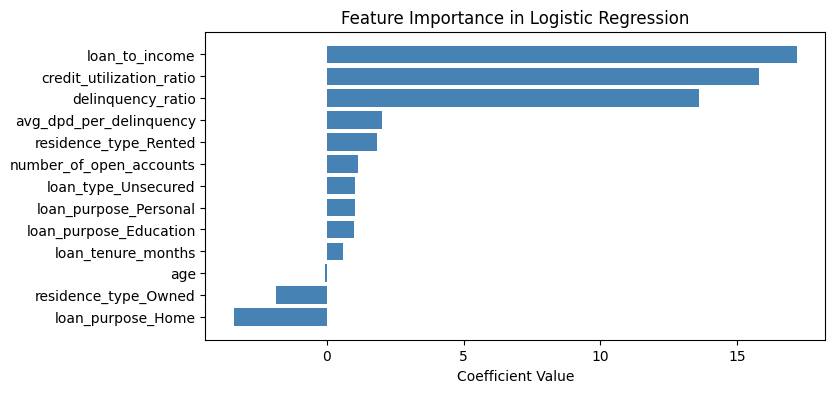

In [130]:
final_model= best_model_logistic

feature_importance= final_model.coef_[0]

coef_df= pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])

coef_df= coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [131]:
# save the model

In [132]:
X_test_encoded.head()

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
19205,0.346,0.755,0.333,0.990,0.550,0.000,0.000,True,False,False,True,False,False
15514,0.481,0.226,1.000,0.323,0.220,0.000,0.000,True,False,True,False,False,False
30367,0.231,0.547,0.667,0.828,0.180,0.000,0.000,True,False,False,False,False,False
35347,0.365,0.755,1.000,0.485,0.571,0.024,0.700,True,False,False,True,False,False
41814,0.577,0.717,0.667,0.980,0.407,0.107,0.640,False,False,False,True,False,False


In [133]:
X_test_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='str')

In [134]:
from joblib import dump

model_data= {
    'model': final_model, 
    'features': X_train_encoded.columns,
    'cols_to_scale': cols_to_scale,
    'scaler': scaler
}

dump(model_data, 'artifacts/model_data.joblib')

['artifacts/model_data.joblib']